[Alzheimer’s Prediction Dataset (Global)](https://www.kaggle.com/datasets/ankushpanday1/alzheimers-prediction-dataset-global)

## Data Card

### About Datset

**Introduction**
This dataset contains 74,283 records from 20 countries, providing insights into Alzheimer's disease risk factors. It includes demographic, lifestyle, medical, and genetic variables, with a biased distribution to reflect real-world disparities across regions.

This dataset is useful for predictive modeling, epidemiological studies, and healthcare research on Alzheimer’s disease.

**Authors**
Ankush Panday

**License**
MIT

In [22]:
import pandas as pd
import seaborn as sns
sns.set_palette("pastel")
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
#from xgboost import XGBClassifier
#from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
pd.set_option('display.max_columns', None)
import warnings
import time
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)
warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline

In [4]:
df = pd.read_csv("data/alzheimers_prediction_dataset.csv")

## Data Analysis

In [5]:
df.head()

,Country,Age,Gender,Education Level,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer’s,Cognitive Test Score,Depression Level,Sleep Quality,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimer’s Diagnosis
0,Spain,90,Male,1,33.0,Medium,Never,Occasionally,No,No,Normal,No,90,Low,Poor,Healthy,High,Retired,Single,No,Low,Medium,High,Urban,No
1,Argentina,72,Male,7,29.9,Medium,Former,Never,No,No,Normal,No,65,Low,Good,Healthy,Medium,Unemployed,Widowed,No,High,Low,High,Urban,No
2,South Africa,86,Female,19,22.9,High,Current,Occasionally,No,Yes,Normal,No,43,High,Good,Average,Medium,Employed,Single,No,Low,Medium,High,Rural,No
3,China,53,Male,17,31.2,Low,Never,Regularly,Yes,No,Normal,No,81,Medium,Average,Healthy,Medium,Retired,Single,No,High,Medium,Low,Rural,No
4,Sweden,58,Female,3,30.0,High,Former,Never,Yes,No,Normal,No,49,High,Poor,Unhealthy,High,Employed,Married,No,Low,Medium,High,Rural,No


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               74283 non-null  str    
 1   Age                                   74283 non-null  int64  
 2   Gender                                74283 non-null  str    
 3   Education Level                       74283 non-null  int64  
 4   BMI                                   74283 non-null  float64
 5   Physical Activity Level               74283 non-null  str    
 6   Smoking Status                        74283 non-null  str    
 7   Alcohol Consumption                   74283 non-null  str    
 8   Diabetes                              74283 non-null  str    
 9   Hypertension                          74283 non-null  str    
 10  Cholesterol Level                     74283 non-null  str    
 11  Family History of Alzheime

In [91]:
df.isnull().sum()

Country                                 0
Age                                     0
Gender                                  0
Education Level                         0
BMI                                     0
Physical Activity Level                 0
Smoking Status                          0
Alcohol Consumption                     0
Diabetes                                0
Hypertension                            0
Cholesterol Level                       0
Family History of Alzheimer’s           0
Cognitive Test Score                    0
Depression Level                        0
Sleep Quality                           0
Dietary Habits                          0
Air Pollution Exposure                  0
Employment Status                       0
Marital Status                          0
Genetic Risk Factor (APOE-ε4 allele)    0
Social Engagement Level                 0
Income Level                            0
Stress Levels                           0
Urban vs Rural Living             

In [92]:
df.duplicated().sum()

np.int64(0)

In [7]:
def histogram(df, label,rotation=None):
    ax = sns.histplot(data=df,x=label,hue=label,legend=False, shrink=.9)
    if rotation:
        ax.tick_params(axis='x', labelrotation=rotation)
    # Add the counts on top of each bar automatically
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    image_title = label.replace(" ", "_")
    plt.savefig(image_title, dpi=300, bbox_inches="tight")
    plt.show()

In [8]:
def histogram_totals(totals,title,xlabel):
    labels = ['Yes', 'No']   
    # 2. Create the bar plot
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(x=labels, y=totals, palette=['#a1c9f4', '#ffb482'])
    for container in ax.containers:
            ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    # 3. Add labels and show
    plt.title(title)
    image_title = title.replace(" ", "_")
    plt.savefig(image_title, dpi=300, bbox_inches="tight")
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()

In [9]:
def binary_plot(df,label,title=None):
    if not title:
        title = label
    df_copy = df.copy()
    df_copy[label] = df_copy[label].replace({0: 'no', 1: 'yes'})
    sns.countplot(data=df_copy, x=label,order=['yes', 'no'], palette=['#a1c9f4', '#ffb482'])
    plt.title(title)
    plt.show()

In [10]:
def yesno_plot(df,label,title=None):
    if not title:
        title = label
        
    sns.countplot(data=df, x=label, palette=['#a1c9f4', '#ffb482'])
    plt.title(title)
    plt.show()

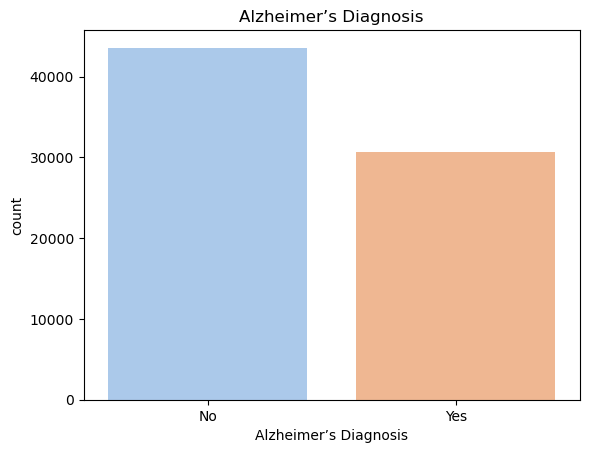

In [11]:
yesno_plot(df,"Alzheimer’s Diagnosis")

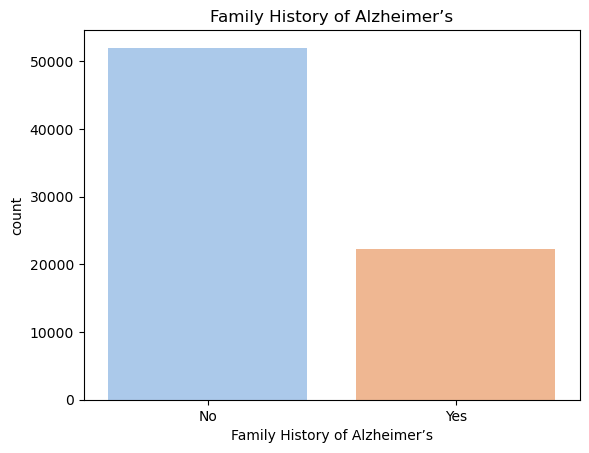

In [12]:
yesno_plot(df,"Family History of Alzheimer’s")

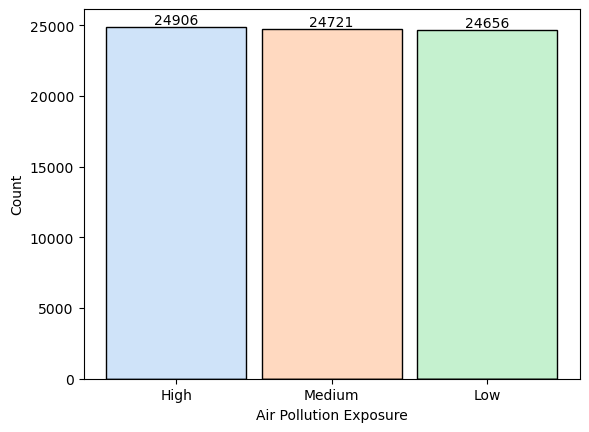

In [73]:
histogram(df,"Air Pollution Exposure")

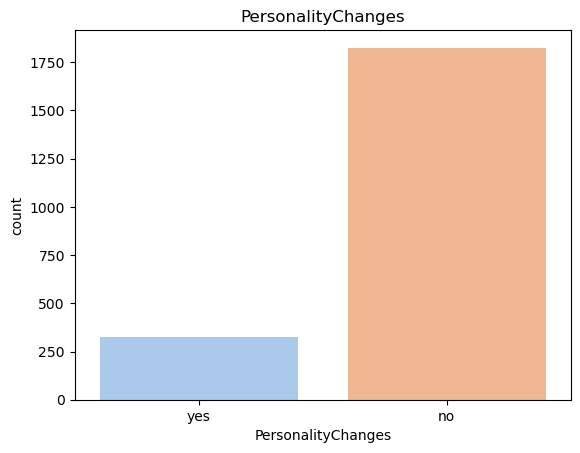

In [57]:
binary_plot(df,"PersonalityChanges")

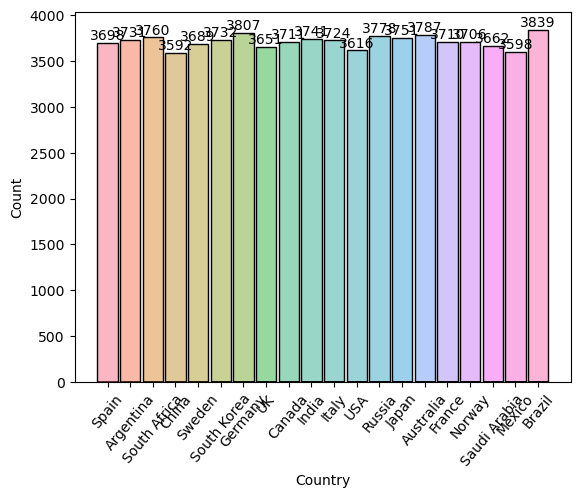

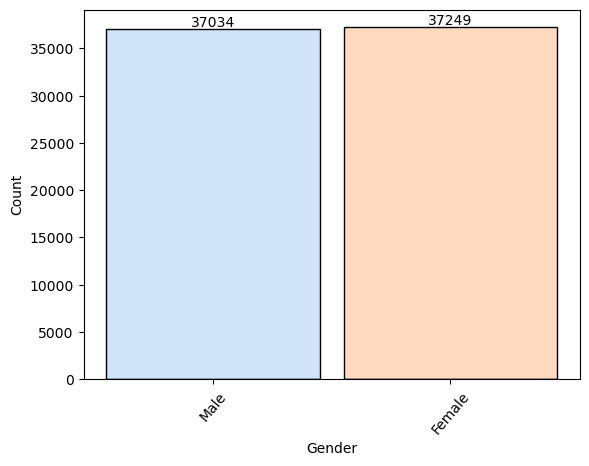

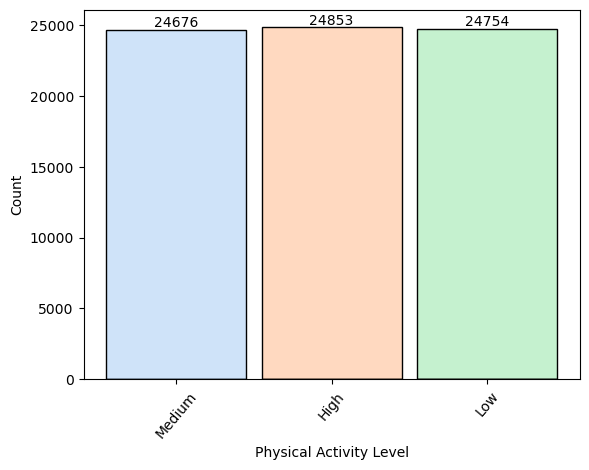

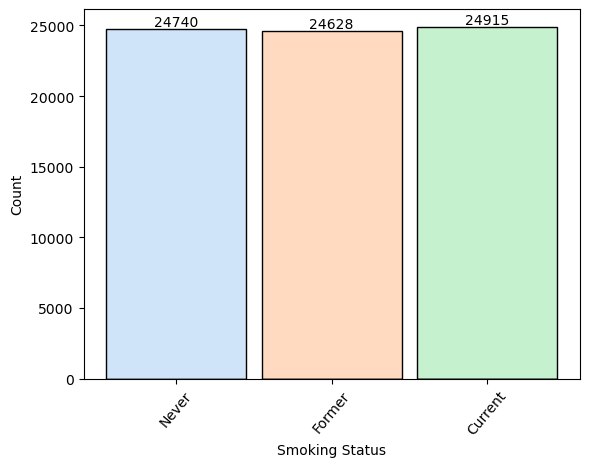

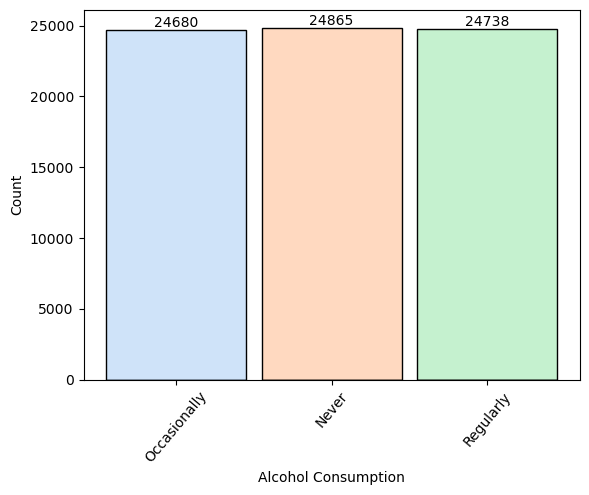

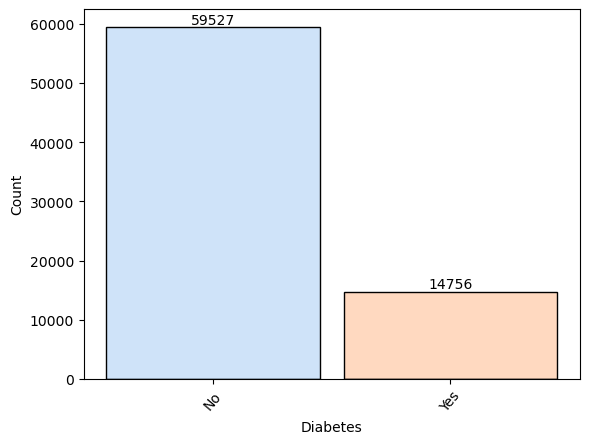

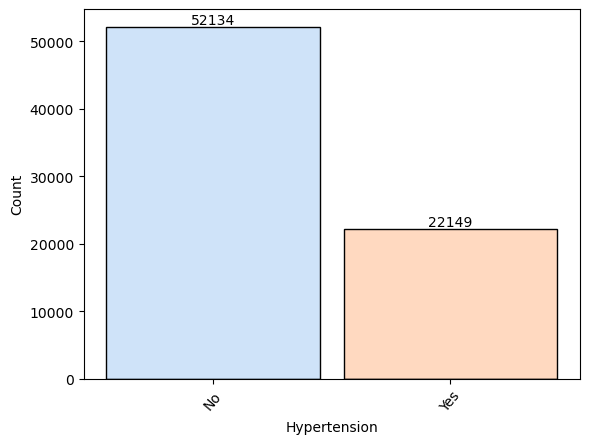

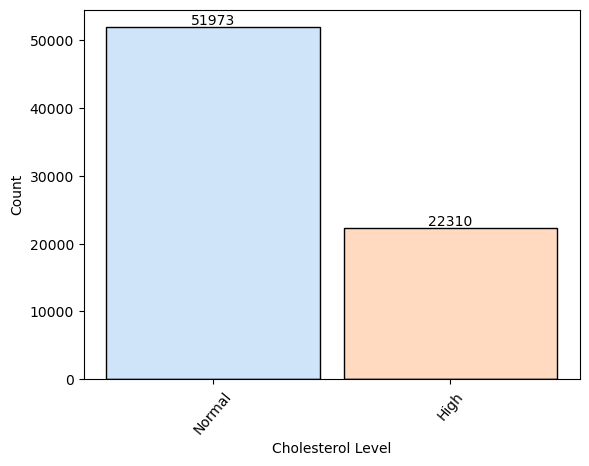

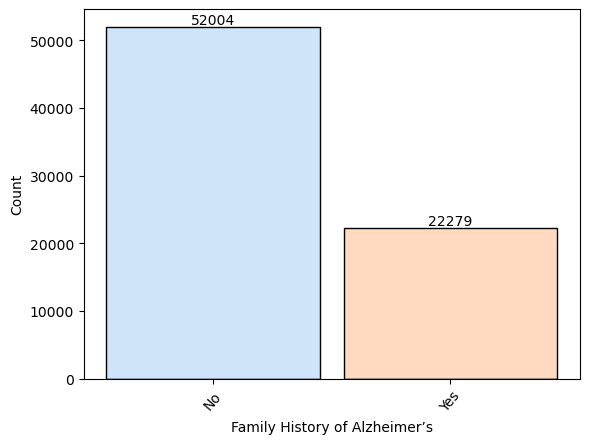

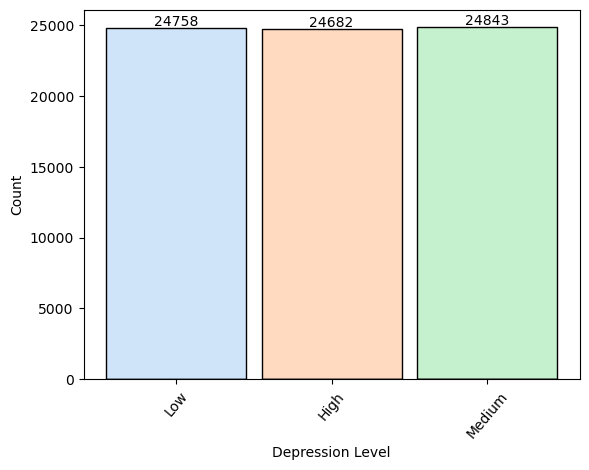

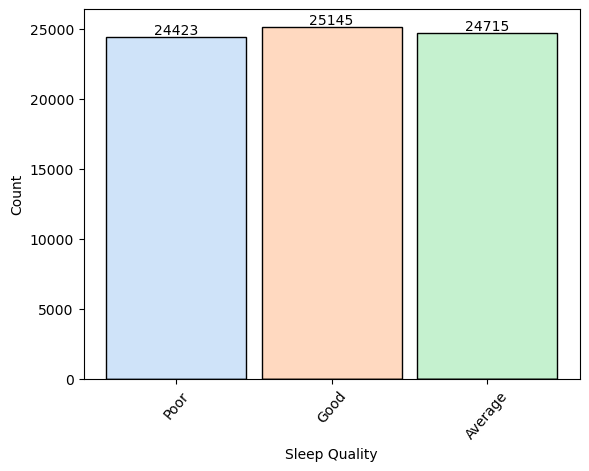

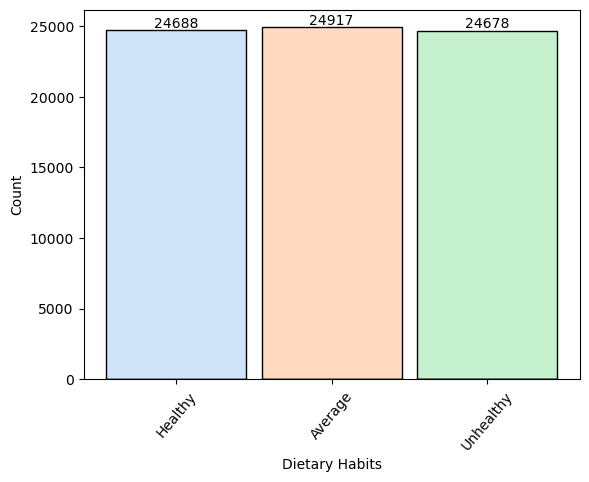

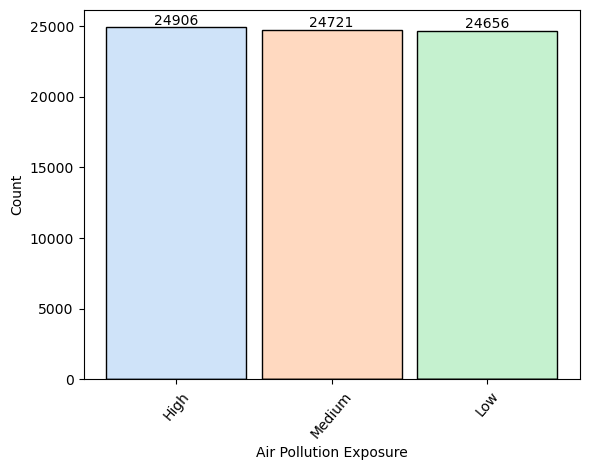

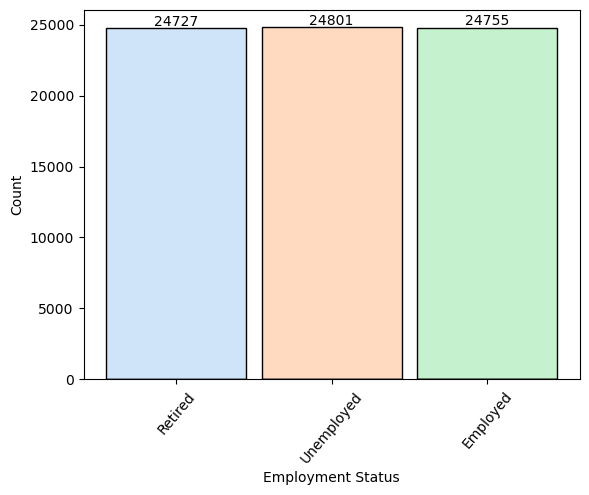

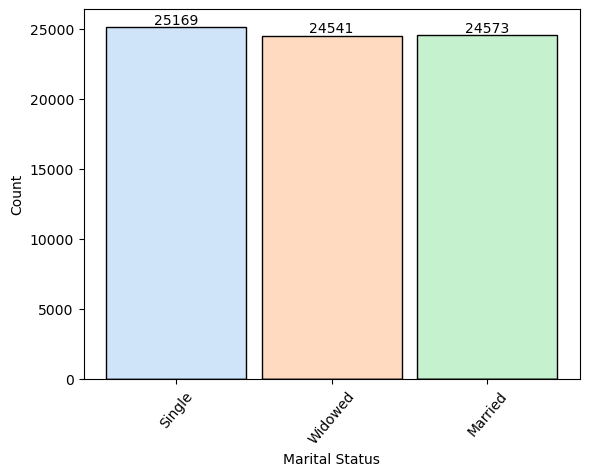

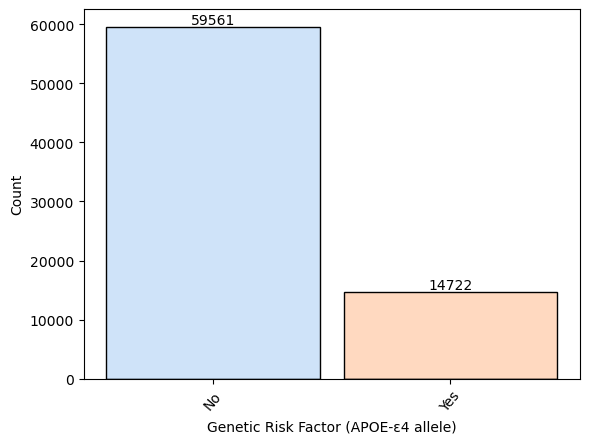

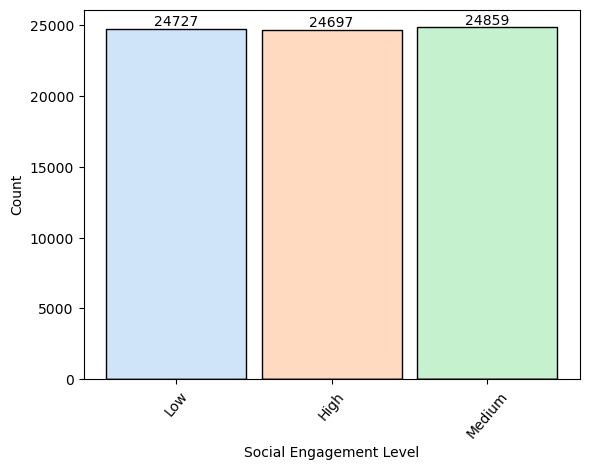

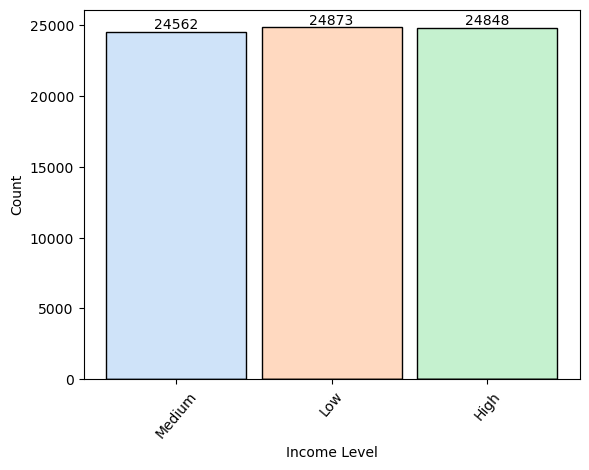

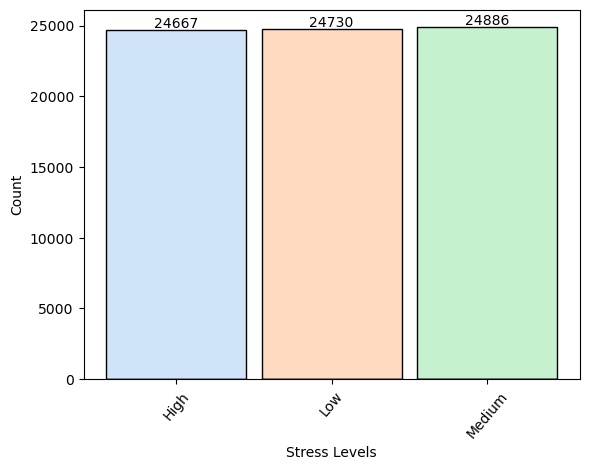

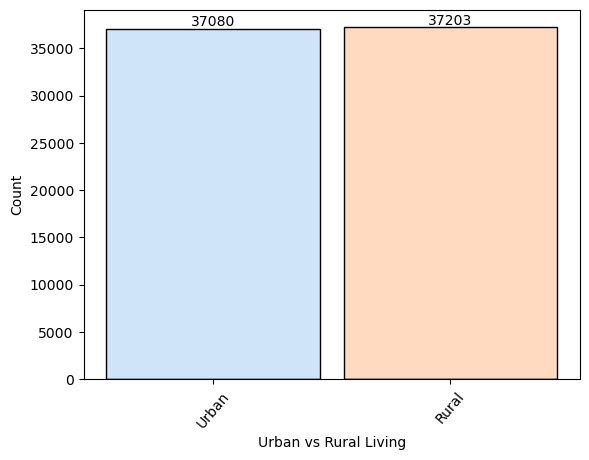

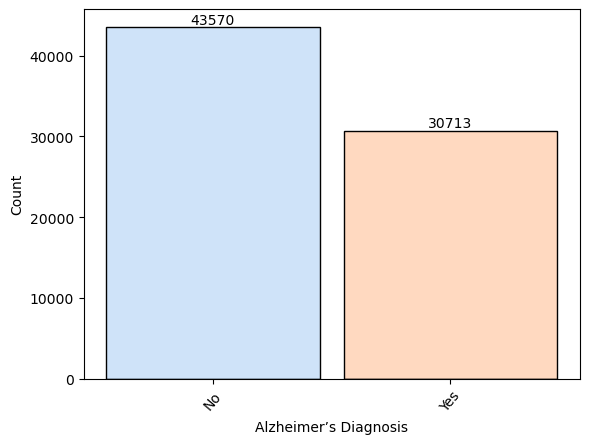

In [89]:
non_float_df = df.select_dtypes(exclude=['number'])
for c in non_float_df.columns:
    histogram(df,c,rotation=50)

https://www.kaggle.com/code/blablabla2004/alzheimers-prediction-dataset

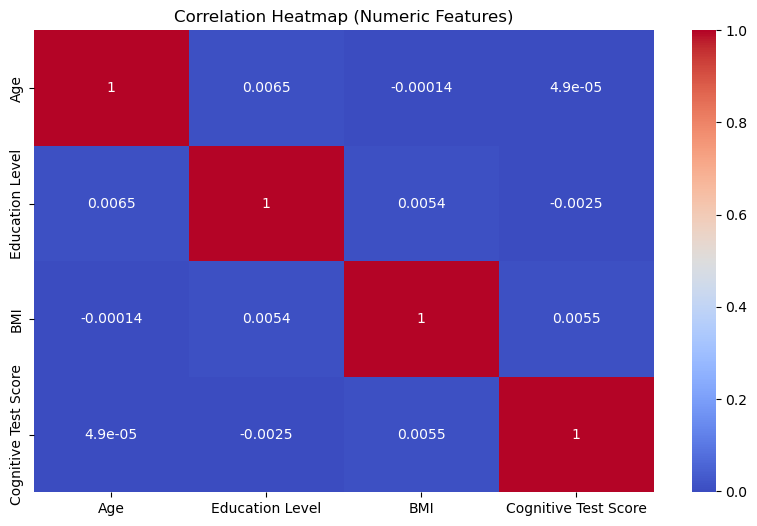

In [93]:

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

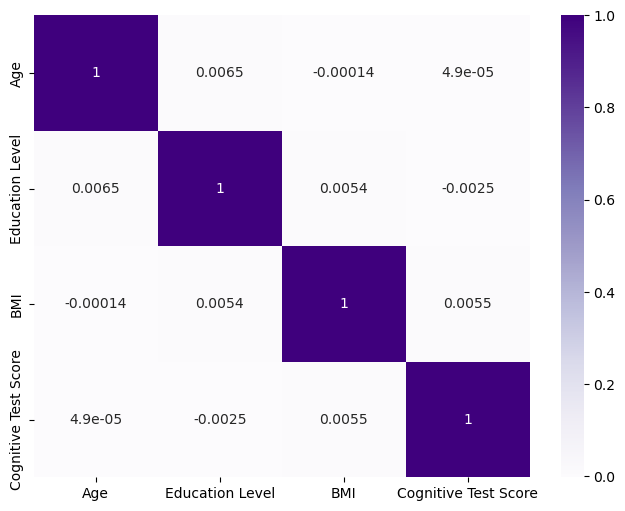

In [97]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Purples")
plt.show()

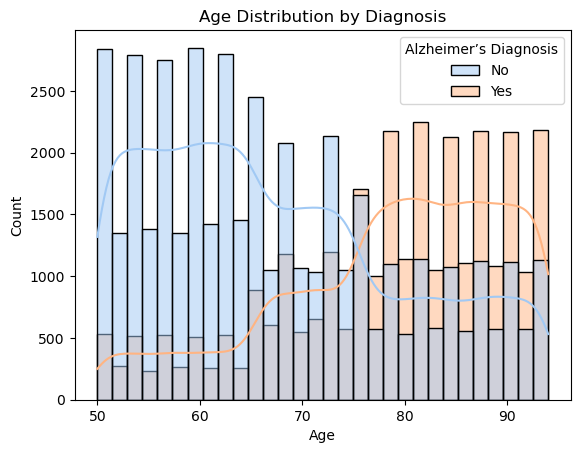

In [94]:
sns.histplot(
    data=df,
    x="Age",
    hue="Alzheimer’s Diagnosis",
    bins=30,
    kde=True
)
plt.title("Age Distribution by Diagnosis")
plt.show()

In [ ]:
plt.figure(figsize=[12, 20])
i = 1

for key, value in categorical_positive_dicts.items():
    plt.subplot(10, 3, i)
    plt.pie(value.values(), labels=value.keys(), startangle=90, autopct="%.2f%%")
    plt.title("Effect of {}\non Alzheimer’s Diagnosis".format(key))
    i = i + 1

plt.tight_layout()
plt.show()

In [104]:
# https://www.kaggle.com/code/engahmedmohamed/alzheimer-s-prediction-eda-ml
fig = px.bar(df['Country'][df['Alzheimer’s Diagnosis'] == 'Yes'].value_counts(),
             color = df['Country'][df['Alzheimer’s Diagnosis'] == 'Yes'].value_counts().index,
             #template = 'plotly_dark',
             title = 'Country with Alzheimer’s Diagnosis',
             labels = {'value':'Count'},
             text_auto = True
             )
pio.renderers.default = 'iframe'
fig.show()

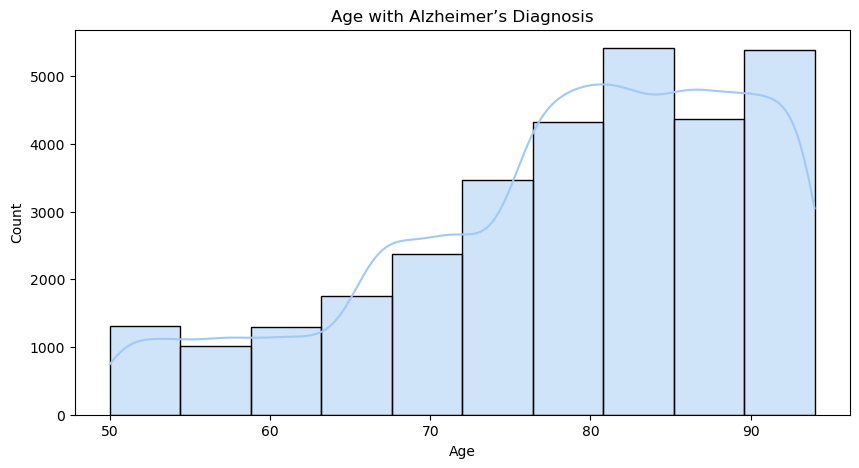

In [105]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'][df['Alzheimer’s Diagnosis'] == 'Yes'], bins=10, kde=True)
plt.title('Age with Alzheimer’s Diagnosis')
plt.show()

In [118]:
def pie(label,title=None):
    if not title:
        title = label

    val=df[label][df['Alzheimer’s Diagnosis']=='Yes'].value_counts().values
    index=df[label][df['Alzheimer’s Diagnosis']=='Yes'].value_counts().index
    fig = px.pie(values=val,names=index,title='Physical Activity',width=400, height=400).update_traces(textinfo='label+percent')
    fig.show()

In [119]:
pie('Physical Activity Level')

In [121]:
categorical_df = df.select_dtypes(exclude='number')
categorical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   Country                               74283 non-null  str  
 1   Gender                                74283 non-null  str  
 2   Physical Activity Level               74283 non-null  str  
 3   Smoking Status                        74283 non-null  str  
 4   Alcohol Consumption                   74283 non-null  str  
 5   Diabetes                              74283 non-null  str  
 6   Hypertension                          74283 non-null  str  
 7   Cholesterol Level                     74283 non-null  str  
 8   Family History of Alzheimer’s         74283 non-null  str  
 9   Depression Level                      74283 non-null  str  
 10  Sleep Quality                         74283 non-null  str  
 11  Dietary Habits                        74283 non-null

In [122]:
categorical_df_positive = categorical_df[categorical_df["Alzheimer’s Diagnosis"] == "Yes"]
categorical_positive_dicts = dict()

for i, column in enumerate(categorical_df_positive, 1):
    if column != "Country" and column != "Alzheimer’s Diagnosis":
        item = categorical_df[column].value_counts().to_dict()
        categorical_positive_dicts[column] = item

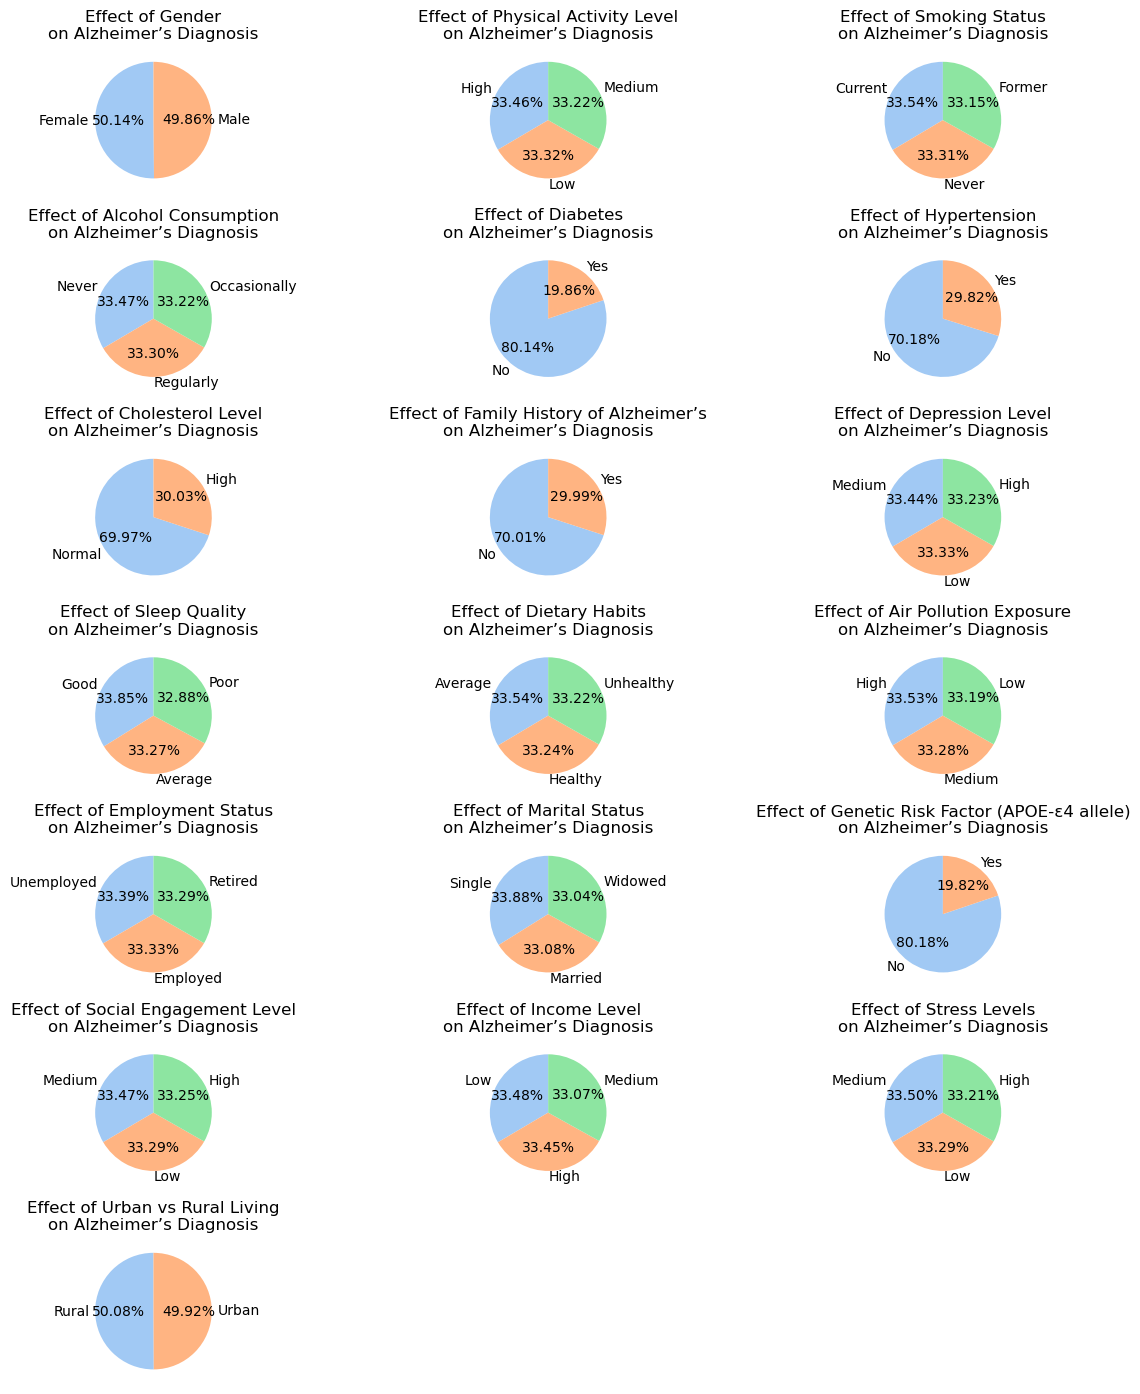

In [123]:
plt.figure(figsize=[12, 20])
i = 1

for key, value in categorical_positive_dicts.items():
    plt.subplot(10, 3, i)
    plt.pie(value.values(), labels=value.keys(), startangle=90, autopct="%.2f%%")
    plt.title("Effect of {}\non Alzheimer’s Diagnosis".format(key))
    i = i + 1

plt.tight_layout()
plt.show()

In [124]:
df.columns

Index(['Country', 'Age', 'Gender', 'Education Level', 'BMI',
       'Physical Activity Level', 'Smoking Status', 'Alcohol Consumption',
       'Diabetes', 'Hypertension', 'Cholesterol Level',
       'Family History of Alzheimer’s', 'Cognitive Test Score',
       'Depression Level', 'Sleep Quality', 'Dietary Habits',
       'Air Pollution Exposure', 'Employment Status', 'Marital Status',
       'Genetic Risk Factor (APOE-ε4 allele)', 'Social Engagement Level',
       'Income Level', 'Stress Levels', 'Urban vs Rural Living',
       'Alzheimer’s Diagnosis'],
      dtype='str')

In [141]:
y = df['Alzheimer’s Diagnosis']
y = y.replace({'Yes': 1, 'No': 0})

In [143]:
X = df.drop(columns='Alzheimer’s Diagnosis')

In [144]:
X

,Country,Age,Gender,Education Level,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer’s,Cognitive Test Score,Depression Level,Sleep Quality,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living
0,Spain,90,Male,1,33.0,Medium,Never,Occasionally,No,No,Normal,No,90,Low,Poor,Healthy,High,Retired,Single,No,Low,Medium,High,Urban
1,Argentina,72,Male,7,29.9,Medium,Former,Never,No,No,Normal,No,65,Low,Good,Healthy,Medium,Unemployed,Widowed,No,High,Low,High,Urban
2,South Africa,86,Female,19,22.9,High,Current,Occasionally,No,Yes,Normal,No,43,High,Good,Average,Medium,Employed,Single,No,Low,Medium,High,Rural
3,China,53,Male,17,31.2,Low,Never,Regularly,Yes,No,Normal,No,81,Medium,Average,Healthy,Medium,Retired,Single,No,High,Medium,Low,Rural
4,Sweden,58,Female,3,30.0,High,Former,Never,Yes,No,Normal,No,49,High,Poor,Unhealthy,High,Employed,Married,No,Low,Medium,High,Rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74278,Russia,60,Female,3,22.6,High,Former,Never,No,No,High,No,42,Medium,Poor,Average,High,Unemployed,Widowed,No,Medium,High,Medium,Rural
74279,UK,58,Male,18,30.6,Low,Never,Occasionally,Yes,No,Normal,No,42,Low,Poor,Average,Medium,Unemployed,Single,No,Medium,High,High,Rural
74280,Spain,57,Female,13,28.2,Medium,Never,Regularly,No,No,High,Yes,61,Low,Good,Healthy,Low,Employed,Single,Yes,High,Low,Low,Rural
74281,Brazil,73,Female,7,29.0,Low,Never,Regularly,No,No,High,No,97,High,Good,Healthy,Low,Employed,Widowed,No,Low,Low,High,Rural


In [155]:
df2 = pd.get_dummies(categorical_df, drop_first=True)
df2

,Country_Australia,Country_Brazil,Country_Canada,Country_China,Country_France,Country_Germany,Country_India,Country_Italy,Country_Japan,Country_Mexico,Country_Norway,Country_Russia,Country_Saudi Arabia,Country_South Africa,Country_South Korea,Country_Spain,Country_Sweden,Country_UK,Country_USA,Gender_Male,Physical Activity Level_Low,Physical Activity Level_Medium,Smoking Status_Former,Smoking Status_Never,Alcohol Consumption_Occasionally,Alcohol Consumption_Regularly,Diabetes_Yes,Hypertension_Yes,Cholesterol Level_Normal,Family History of Alzheimer’s_Yes,Depression Level_Low,Depression Level_Medium,Sleep Quality_Good,Sleep Quality_Poor,Dietary Habits_Healthy,Dietary Habits_Unhealthy,Air Pollution Exposure_Low,Air Pollution Exposure_Medium,Employment Status_Retired,Employment Status_Unemployed,Marital Status_Single,Marital Status_Widowed,Genetic Risk Factor (APOE-ε4 allele)_Yes,Social Engagement Level_Low,Social Engagement Level_Medium,Income Level_Low,Income Level_Medium,Stress Levels_Low,Stress Levels_Medium,Urban vs Rural Living_Urban,Alzheimer’s Diagnosis_Yes
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,True,True,False,False,False,True,False,True,False,False,True,True,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,False,True,False,True,False,True,False,True,False,False,True,False,True,False,True,False,False,False,True,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,True,False,True,True,False,True,False,False,True,False,False,True,False,False,True,True,False,True,False,False,False,False,False,True,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74278,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,False,True,False,False
74279,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,True,True,False,True,False,True,False,True,False,False,True,False,False,False,True,False,True,True,False,False,False,True,False,False,False,False,False,False
74280,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,True,False,False,False,True,True,False,True,False,True,False,True,False,False,False,True,False,True,False,False,True,False,True,False,False,False
74281,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False


,Country,Age,Gender,Education Level,BMI,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer’s,Cognitive Test Score,Sleep Quality,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Urban vs Rural Living,Alzheimer’s Diagnosis,Stress Levels_Low,Stress Levels_Medium,Depression Level_Low,Depression Level_Medium,Physical Activity Level_Low,Physical Activity Level_Medium
0,Spain,90,Male,1,33.0,Never,Occasionally,No,No,Normal,No,90,Poor,Healthy,High,Retired,Single,No,Low,Medium,Urban,No,False,False,True,False,False,True
1,Argentina,72,Male,7,29.9,Former,Never,No,No,Normal,No,65,Good,Healthy,Medium,Unemployed,Widowed,No,High,Low,Urban,No,False,False,True,False,False,True
2,South Africa,86,Female,19,22.9,Current,Occasionally,No,Yes,Normal,No,43,Good,Average,Medium,Employed,Single,No,Low,Medium,Rural,No,False,False,False,False,False,False
3,China,53,Male,17,31.2,Never,Regularly,Yes,No,Normal,No,81,Average,Healthy,Medium,Retired,Single,No,High,Medium,Rural,No,True,False,False,True,True,False
4,Sweden,58,Female,3,30.0,Former,Never,Yes,No,Normal,No,49,Poor,Unhealthy,High,Employed,Married,No,Low,Medium,Rural,No,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74278,Russia,60,Female,3,22.6,Former,Never,No,No,High,No,42,Poor,Average,High,Unemployed,Widowed,No,Medium,High,Rural,No,False,True,False,True,False,False
74279,UK,58,Male,18,30.6,Never,Occasionally,Yes,No,Normal,No,42,Poor,Average,Medium,Unemployed,Single,No,Medium,High,Rural,No,False,False,True,False,True,False
74280,Spain,57,Female,13,28.2,Never,Regularly,No,No,High,Yes,61,Good,Healthy,Low,Employed,Single,Yes,High,Low,Rural,No,True,False,True,False,False,True
74281,Brazil,73,Female,7,29.0,Never,Regularly,No,No,High,No,97,Good,Healthy,Low,Employed,Widowed,No,Low,Low,Rural,No,False,False,False,False,True,False


# Start Over

In [14]:
binary_map = {'Yes': 1, 'No': 0}
for col in ['Diabetes', 'Hypertension', 'Family History of Alzheimer’s',
            'Genetic Risk Factor (APOE-ε4 allele)']:
    df[col] = df[col].map(binary_map)

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Urban vs Rural Living'] = df['Urban vs Rural Living'].map({'Urban': 1, 'Rural': 0})
df['Cholesterol Level'] = df['Cholesterol Level'].map({'High': 1, 'Normal': 0})
df["Alzheimer’s Diagnosis"] = df["Alzheimer’s Diagnosis"].map(binary_map)  # your target

In [15]:
lmh = {'Low': 0, 'Medium': 1, 'High': 2}
for col in ['Stress Levels', 'Depression Level', 'Physical Activity Level',
            'Air Pollution Exposure', 'Social Engagement Level', 'Income Level']:
    df[col] = df[col].map(lmh)

df['Sleep Quality'] = df['Sleep Quality'].map({'Poor': 0, 'Average': 1, 'Good': 2})
df['Dietary Habits'] = df['Dietary Habits'].map({'Unhealthy': 0, 'Average': 1, 'Healthy': 2})

In [16]:
nominal_cols = ['Country', 'Smoking Status', 'Alcohol Consumption',
                'Employment Status', 'Marital Status']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
df = df.astype({col: int for col in df.select_dtypes('bool').columns})

In [17]:
y = df["Alzheimer’s Diagnosis"]
X =  df.drop(columns='Alzheimer’s Diagnosis')

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
def train(X_train, X_test, y_train, y_test): 

    # Scale features (needed for LogReg + KNN; RF/GBM are scale-invariant)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = []
    
    def evaluate(name, model, Xtr, Xte):
        start = time.time()
        model.fit(Xtr, y_train)
        fit_time = time.time() - start
    
        preds = model.predict(Xte)
        proba = model.predict_proba(Xte)[:, 1]
    
        row = {
            'Model': name,
            'Accuracy': accuracy_score(y_test, preds),
            'Precision': precision_score(y_test, preds),
            'Recall': recall_score(y_test, preds),
            'F1': f1_score(y_test, preds),
            'ROC-AUC': roc_auc_score(y_test, proba),
            'Fit Time (s)': round(fit_time, 2)
        }
        results.append(row)
        print(f"--- {name} ---")
        print(confusion_matrix(y_test, preds))
        print(classification_report(y_test, preds, target_names=['No', 'Yes']))
        return model
    
    # Logistic Regression
    log_reg = evaluate('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),
                        X_train_scaled, X_test_scaled)
    lr_coef = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
    
    # Random Forest
    rf = evaluate('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                  X_train, X_test)
    rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    # Gradient Boosting
    gb = evaluate('Gradient Boosting', GradientBoostingClassifier(random_state=42),
                  X_train, X_test)
    gb_imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    
    knn = evaluate('KNN', KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
                   X_train_scaled, X_test_scaled)
    
    results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
    print(results_df.to_string(index=False))
    print()
    print("=== Gradient Boosting: Top 15 Feature Importances ===")
    print(gb_imp.head(15))
    print()
    print("=== Random Forest: Top 15 Feature Importances ===")
    print(rf_imp.head(15))
    print()
    print("=== Logistic Regression: Top 15 Coefficients (by abs value) ===")
    print(lr_coef.head(15))

In [23]:
train(X_train, X_test, y_train, y_test)

--- Logistic Regression ---
[[6940 1774]
 [2412 3731]]
              precision    recall  f1-score   support

          No       0.74      0.80      0.77      8714
         Yes       0.68      0.61      0.64      6143

    accuracy                           0.72     14857
   macro avg       0.71      0.70      0.70     14857
weighted avg       0.72      0.72      0.72     14857

--- Random Forest ---
[[6793 1921]
 [2149 3994]]
              precision    recall  f1-score   support

          No       0.76      0.78      0.77      8714
         Yes       0.68      0.65      0.66      6143

    accuracy                           0.73     14857
   macro avg       0.72      0.71      0.72     14857
weighted avg       0.72      0.73      0.73     14857

--- Gradient Boosting ---
[[6591 2123]
 [1866 4277]]
              precision    recall  f1-score   support

          No       0.78      0.76      0.77      8714
         Yes       0.67      0.70      0.68      6143

    accuracy             

In [163]:
import time
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

# Scale features (needed for LogReg + KNN; RF/GBM are scale-invariant)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

def evaluate(name, model, Xtr, Xte):
    start = time.time()
    model.fit(Xtr, y_train)
    fit_time = time.time() - start

    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]

    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'Fit Time (s)': round(fit_time, 2)
    }
    results.append(row)
    print(f"--- {name} ---")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds, target_names=['No', 'Yes']))
    return model

log_reg = evaluate('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),
                    X_train_scaled, X_test_scaled)

rf = evaluate('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
              X_train, X_test)

gb = evaluate('Gradient Boosting', GradientBoostingClassifier(random_state=42),
              X_train, X_test)

knn = evaluate('KNN', KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
               X_train_scaled, X_test_scaled)

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

--- Logistic Regression ---
[[6940 1774]
 [2412 3731]]
              precision    recall  f1-score   support

          No       0.74      0.80      0.77      8714
         Yes       0.68      0.61      0.64      6143

    accuracy                           0.72     14857
   macro avg       0.71      0.70      0.70     14857
weighted avg       0.72      0.72      0.72     14857

--- Random Forest ---
[[6793 1921]
 [2149 3994]]
              precision    recall  f1-score   support

          No       0.76      0.78      0.77      8714
         Yes       0.68      0.65      0.66      6143

    accuracy                           0.73     14857
   macro avg       0.72      0.71      0.72     14857
weighted avg       0.72      0.73      0.73     14857

--- Gradient Boosting ---
[[6591 2123]
 [1866 4277]]
              precision    recall  f1-score   support

          No       0.78      0.76      0.77      8714
         Yes       0.67      0.70      0.68      6143

    accuracy             

# Drop the Biology

In [25]:
df = pd.read_csv("data/alzheimers_prediction_dataset.csv")
df.columns

Index(['Country', 'Age', 'Gender', 'Education Level', 'BMI',
       'Physical Activity Level', 'Smoking Status', 'Alcohol Consumption',
       'Diabetes', 'Hypertension', 'Cholesterol Level',
       'Family History of Alzheimer’s', 'Cognitive Test Score',
       'Depression Level', 'Sleep Quality', 'Dietary Habits',
       'Air Pollution Exposure', 'Employment Status', 'Marital Status',
       'Genetic Risk Factor (APOE-ε4 allele)', 'Social Engagement Level',
       'Income Level', 'Stress Levels', 'Urban vs Rural Living',
       'Alzheimer’s Diagnosis'],
      dtype='str')

In [24]:
# --- Drop the two genetic/family-history columns ---
df = df.drop(columns=['Family History of Alzheimer’s',
                       'Genetic Risk Factor (APOE-ε4 allele)',
                       'Country', 'Age'])

KeyError: "['Country'] not found in axis"

In [204]:

# --- Binary Yes/No & 2-category columns -> 0/1 ---
binary_map = {'Yes': 1, 'No': 0}
for col in ['Diabetes', 'Hypertension']:
    df[col] = df[col].map(binary_map)

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Urban vs Rural Living'] = df['Urban vs Rural Living'].map({'Urban': 1, 'Rural': 0})
df['Cholesterol Level'] = df['Cholesterol Level'].map({'High': 1, 'Normal': 0})
df["Alzheimer’s Diagnosis"] = df["Alzheimer’s Diagnosis"].map(binary_map)

# --- Ordinal Low/Medium/High-type -> 0/1/2 ---
lmh = {'Low': 0, 'Medium': 1, 'High': 2}
for col in ['Stress Levels', 'Depression Level', 'Physical Activity Level',
            'Air Pollution Exposure', 'Social Engagement Level', 'Income Level']:
    df[col] = df[col].map(lmh)

df['Sleep Quality'] = df['Sleep Quality'].map({'Poor': 0, 'Average': 1, 'Good': 2})
df['Dietary Habits'] = df['Dietary Habits'].map({'Unhealthy': 0, 'Average': 1, 'Healthy': 2})

# --- True nominal, no order -> one-hot ---
nominal_cols = ['Smoking Status', 'Alcohol Consumption',
                'Employment Status', 'Marital Status']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
df = df.astype({col: int for col in df.select_dtypes('bool').columns})

print("Final shape:", df.shape)  # (74283, 45) -- was 47, now 2 fewer

Final shape: (74283, 25)


In [205]:
y = df["Alzheimer’s Diagnosis"]
X =  df.drop(columns='Alzheimer’s Diagnosis')

In [206]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
def train(X_train, X_test, y_train, y_test): 

    # Scale features (needed for LogReg + KNN; RF/GBM are scale-invariant)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = []
    
    def evaluate(name, model, Xtr, Xte):
        start = time.time()
        model.fit(Xtr, y_train)
        fit_time = time.time() - start
    
        preds = model.predict(Xte)
        proba = model.predict_proba(Xte)[:, 1]
    
        row = {
            'Model': name,
            'Accuracy': accuracy_score(y_test, preds),
            'Precision': precision_score(y_test, preds),
            'Recall': recall_score(y_test, preds),
            'F1': f1_score(y_test, preds),
            'ROC-AUC': roc_auc_score(y_test, proba),
            'Fit Time (s)': round(fit_time, 2)
        }
        results.append(row)
        print(f"--- {name} ---")
        print(confusion_matrix(y_test, preds))
        print(classification_report(y_test, preds, target_names=['No', 'Yes']))
        return model
    
    # Logistic Regression
    log_reg = evaluate('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),
                        X_train_scaled, X_test_scaled)
    lr_coef = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
    
    # Random Forest
    rf = evaluate('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                  X_train, X_test)
    rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    # Gradient Boosting
    gb = evaluate('Gradient Boosting', GradientBoostingClassifier(random_state=42),
                  X_train, X_test)
    gb_imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    
    knn = evaluate('KNN', KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
                   X_train_scaled, X_test_scaled)
    
    results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
    print(results_df.to_string(index=False))
    print()
    print("=== Gradient Boosting: Top 15 Feature Importances ===")
    print(gb_imp.head(15))
    print()
    print("=== Random Forest: Top 15 Feature Importances ===")
    print(rf_imp.head(15))
    print()
    print("=== Logistic Regression: Top 15 Coefficients (by abs value) ===")
    print(lr_coef.head(15))

In [207]:
# Scale features (needed for LogReg + KNN; RF/GBM are scale-invariant)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

def evaluate(name, model, Xtr, Xte):
    start = time.time()
    model.fit(Xtr, y_train)
    fit_time = time.time() - start

    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]

    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'Fit Time (s)': round(fit_time, 2)
    }
    results.append(row)
    print(f"--- {name} ---")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds, target_names=['No', 'Yes']))
    return model

# Logistic Regression
log_reg = evaluate('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),
                    X_train_scaled, X_test_scaled)
lr_coef = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

# Random Forest
rf = evaluate('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
              X_train, X_test)
rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Gradient Boosting
gb = evaluate('Gradient Boosting', GradientBoostingClassifier(random_state=42),
              X_train, X_test)
gb_imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)


knn = evaluate('KNN', KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
               X_train_scaled, X_test_scaled)

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

/home/fazuskazoo/anaconda3/envs/ucb/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.

/home/fazuskazoo/anaconda3/envs/ucb/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/fazuskazoo/anaconda3/envs/ucb/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/fazuskazoo/anaconda3/envs/ucb/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no 

--- Logistic Regression ---
[[8714    0]
 [6143    0]]
              precision    recall  f1-score   support

          No       0.59      1.00      0.74      8714
         Yes       0.00      0.00      0.00      6143

    accuracy                           0.59     14857
   macro avg       0.29      0.50      0.37     14857
weighted avg       0.34      0.59      0.43     14857

--- Random Forest ---
[[8178  536]
 [5776  367]]
              precision    recall  f1-score   support

          No       0.59      0.94      0.72      8714
         Yes       0.41      0.06      0.10      6143

    accuracy                           0.58     14857
   macro avg       0.50      0.50      0.41     14857
weighted avg       0.51      0.58      0.47     14857

--- Gradient Boosting ---
[[8710    4]
 [6141    2]]
              precision    recall  f1-score   support

          No       0.59      1.00      0.74      8714
         Yes       0.33      0.00      0.00      6143

    accuracy             

In [201]:
print("=== Gradient Boosting: Top 15 Feature Importances ===")
print(gb_imp.head(15))
print()
print("=== Random Forest: Top 15 Feature Importances ===")
print(rf_imp.head(15))
print()
print("=== Logistic Regression: Top 15 Coefficients (by abs value) ===")
print(lr_coef.head(15))

=== Gradient Boosting: Top 15 Feature Importances ===
Age                        0.976609
BMI                        0.008542
Cognitive Test Score       0.004509
Education Level            0.003490
Stress Levels              0.000720
Dietary Habits             0.000689
Physical Activity Level    0.000643
Diabetes                   0.000611
Cholesterol Level          0.000552
Social Engagement Level    0.000512
Income Level               0.000425
Hypertension               0.000405
Urban vs Rural Living      0.000361
Marital Status_Single      0.000360
Smoking Status_Never       0.000244
dtype: float64

=== Random Forest: Top 15 Feature Importances ===
Age                        0.274475
BMI                        0.109585
Cognitive Test Score       0.101827
Education Level            0.079262
Sleep Quality              0.029827
Physical Activity Level    0.029417
Air Pollution Exposure     0.029384
Depression Level           0.029286
Stress Levels              0.029218
Social Engagemen